In [122]:
import numpy as np


class LogReg:
    def __init__(self, lr=0.1, C=1, num_iter=1000):
        self.lr = lr
        self.C = C
        self.num_iter = num_iter
        self.losses = []

    def sigmoid_usual(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid(self, z):
        z = np.array(z, dtype=float)

        positive = z >= 0
        negative = ~positive

        out = np.empty_like(z, dtype=float)

        out[positive] = 1 / (1 + np.exp(-z[positive]))
        out[negative] = np.exp(z[negative]) / (1 + np.exp(z[negative]))

        return out

    def loss(self, probs, y, n):
        eps = 1e-15
        probs = np.clip(probs, eps, 1 - eps)

        loss = -(1 / n) * np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

        return loss

    def gradients(self, n, X, y, logits, metrics="neg_log_loss"):
        if metrics == "neg_log_loss":
            return {
                "weights": (1 / n) * np.matmul(X.T, (logits - y))
                + (1 / self.C) * self.weights,
                "bias": (1 / n) * sum(logits - y),
            }

    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias

    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        n = X.shape[0]

        for i in range(self.num_iter):
            logits = np.matmul(X, self.weights) + self.bias
            probs = self.sigmoid(logits)

            grads = self.gradients(n, X, y, probs)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(probs, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

    
    def predict(self, X_test):
        probabilities = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        classes = (probabilities >= 0.5).astype(int)
        return classes

    def predict_proba(self, X_test):
        p1 = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        p0 = 1 - p1
        return np.vstack([p0, p1]).T

In [123]:
class LinearRegression:
    def __init__(self, lr=0.001, alpha=1, num_iter=1000):
        self.lr = lr
        self.alpha = alpha
        self.num_iter = num_iter
        self.weights = np.array([])
        self.bias = 0
        self.losses = []

    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2)
        return loss
    
    def gradients(self, n, X, y, logits, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (logits - y))
                + 2 * self.alpha * self.weights,
                "bias": (2 / n) * sum(logits - y),
            }
        
    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias
    
    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        n = X.shape[0]
        
        for i in range(self.num_iter):
            logits = np.matmul(X, self.weights) + self.bias

            grads = self.gradients(n, X, y, logits)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(logits, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

    def predict(self, X_test):
        predictions = self.bias + np.dot(X_test, self.weights)
        return predictions


In [124]:
from sklearn.datasets import load_breast_cancer

np.set_printoptions(suppress=True)

early_stopping_value = 0.000001
num_iterations = 100000
C = 1

X, y = load_breast_cancer(return_X_y=True)

In [125]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [126]:
log_reg = LogReg(num_iter=num_iterations, C=C)
log_reg.fit(X_train, y_train)

print(f"Weights: {log_reg.weights}")
print(f"Bias: {log_reg.bias}")
predictions = log_reg.predict(X_test) 
probs = log_reg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Stopped on iteration 250
Weights: [-0.11661718 -0.08031177 -0.11655286 -0.10872729 -0.05407246 -0.07375407
 -0.09183193 -0.11693729 -0.03997066  0.02687549 -0.07917976  0.00577266
 -0.07302825 -0.07199202  0.01163332 -0.01447236 -0.00749645 -0.04546066
  0.01532288  0.01755947 -0.12580702 -0.09233138 -0.12414109 -0.11271482
 -0.07860535 -0.0832951  -0.09371528 -0.12522354 -0.07266199 -0.0423295 ]
Bias: 0.5909721778054303
Accuracy: 0.9824561403508771
Logloss: 0.3013254705951574


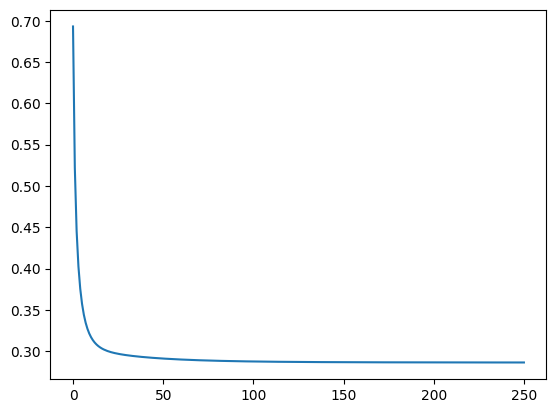

In [127]:
plt.plot(log_reg.losses)

In [128]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True)

scaler = StandardScaler()

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X, y, test_size=0.3
)

X_train_linear = scaler.fit_transform(X_train_linear)
X_test_linear = scaler.transform(X_test_linear)


In [129]:
alpha = 0.001
linreg = LinearRegression(num_iter=10000, alpha=alpha)
linreg.fit(X_train_linear, y_train_linear)

print(f"Weights: {linreg.weights}")
print(f"Bias: {linreg.bias}")
predictions = linreg.predict(X_test_linear) 

print(f"Accuracy: {mean_squared_error(y_test_linear, predictions)}")

Weights: [ -3.60775226 -11.6027434   27.48791578  14.188838   -10.73146507
  -1.47110222  -9.53823013   3.60536184  26.10440176   4.62704956]
Bias: 150.54045277029903
Accuracy: 2870.8039767883038


In [130]:
predictions

array([169.35300926, 196.96299082,  94.68602464, 112.16269984,
       142.09690805,  85.535453  , 135.11321198, 167.81151602,
       213.02725721, 160.37918112, 108.64160803,  83.26099625,
       164.72046862, 220.24744434,  75.14254866, 159.37415726,
       177.24961539, 168.45898236,  88.17034957, 178.24282421,
       105.38661124, 184.13126913,  73.91212852, 192.45137112,
       187.86446885, 115.76328568, 213.55451852,  84.62410669,
       144.704719  , 163.24226843, 136.05126806, 167.65069393,
        56.14877504, 122.94694555, 151.94439019,  81.78172646,
       268.42930828, 104.12953968,  79.83082949, 114.95146668,
        82.16505851, 267.52222565, 298.23521688,  49.65233861,
       265.959401  ,  88.37346431, 116.1408548 , 303.27944557,
       173.33855443, 172.56455305, 127.88170253, 218.47428207,
       161.13073076, 246.12969779,  82.756225  , 164.24654909,
       137.19430058,  82.09949137, 179.21660101, 140.52547997,
       184.48763139,  39.0783264 , 195.28903678, 167.89

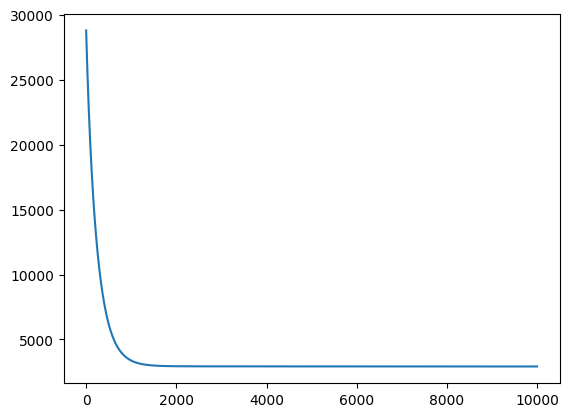

In [131]:
plt.plot(linreg.losses)